In [1]:
import os
import re
import glob
import json

from matplotlib import pyplot as plt

In [2]:

def load_metadata_files(min_number=79880, directory="./dataset"):
    data = []

    all_question_types = []

    pattern = os.path.join(directory, "metadata*.jsonl")
    regex = re.compile(r"metadata(\d{5})_(\d{1})\.jsonl$")

    matching_files = []
    for filepath in glob.glob(pattern):
        filename = os.path.basename(filepath)
        match = regex.match(filename)

        if match and int(match.group(1)) >= min_number:
            matching_files.append(filepath)

    for filepath in sorted(matching_files):
        with open(filepath, "r", encoding="utf-8") as f:
            for line in f:
               j = json.loads(line)
               q = j["graph"]["questions"]
               all_question_types.extend([ques["type"] for ques in q])


    return all_question_types

# Load files
question_types = load_metadata_files(min_number=79880)

(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

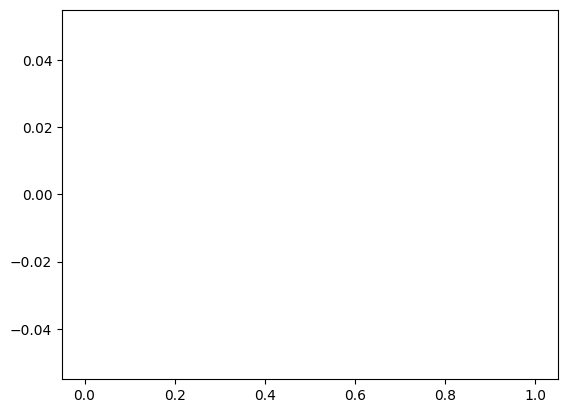

In [3]:
plt.hist(question_types)